In [3]:
%pip install kagglehub


Note: you may need to restart the kernel to use updated packages.


In [4]:
# Install dependencies as needed:
# pip install kagglehub[pandas-datasets]
import kagglehub
from kagglehub import KaggleDatasetAdapter

# Set the path to the file you'd like to load
file_path = "sleep_mobile_stress_dataset_15000.csv"

# Load the latest version
df = kagglehub.dataset_load(
  KaggleDatasetAdapter.PANDAS,
  "jayjoshi37/sleep-screen-time-and-stress-analysis",
  file_path,
  # Provide any additional arguments like 
  # sql_query or pandas_kwargs. See the 
  # documenation for more information:
  # https://github.com/Kaggle/kagglehub/blob/main/README.md#kaggledatasetadapterpandas
)

print("First 5 records:", df.head())

First 5 records:    user_id  age  gender         occupation  daily_screen_time_hours  \
0        1   56  Female           Designer                     3.26   
1        2   46  Female            Teacher                     1.85   
2        3   32  Female           Designer                     3.04   
3        4   25    Male  Software Engineer                     9.00   
4        5   38  Female            Teacher                     3.52   

   phone_usage_before_sleep_minutes  sleep_duration_hours  \
0                                86                  5.31   
1                                32                  7.36   
2                               107                  4.50   
3                                36                  6.68   
4                                56                  7.57   

   sleep_quality_score  stress_level  caffeine_intake_cups  \
0                 7.72          3.49                     0   
1                 9.70          3.01                     0   
2  

In [5]:
import pandas as pd
df.shape

(15000, 13)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 13 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   user_id                           15000 non-null  int64  
 1   age                               15000 non-null  int64  
 2   gender                            15000 non-null  object 
 3   occupation                        15000 non-null  object 
 4   daily_screen_time_hours           15000 non-null  float64
 5   phone_usage_before_sleep_minutes  15000 non-null  int64  
 6   sleep_duration_hours              15000 non-null  float64
 7   sleep_quality_score               15000 non-null  float64
 8   stress_level                      15000 non-null  float64
 9   caffeine_intake_cups              15000 non-null  int64  
 10  physical_activity_minutes         15000 non-null  int64  
 11  notifications_received_per_day    15000 non-null  int64  
 12  ment

In [7]:
df.isna().sum()

user_id                             0
age                                 0
gender                              0
occupation                          0
daily_screen_time_hours             0
phone_usage_before_sleep_minutes    0
sleep_duration_hours                0
sleep_quality_score                 0
stress_level                        0
caffeine_intake_cups                0
physical_activity_minutes           0
notifications_received_per_day      0
mental_fatigue_score                0
dtype: int64

In [8]:
df_update = df.copy()
df_update["gender"] = df_update["gender"].astype(str)
df_update["occupation"] = df_update["gender"].astype(str)
df_update.dtypes

user_id                               int64
age                                   int64
gender                               object
occupation                           object
daily_screen_time_hours             float64
phone_usage_before_sleep_minutes      int64
sleep_duration_hours                float64
sleep_quality_score                 float64
stress_level                        float64
caffeine_intake_cups                  int64
physical_activity_minutes             int64
notifications_received_per_day        int64
mental_fatigue_score                float64
dtype: object

In [9]:
#dataset does not contain any date values to use pd.to_datetime
df_update["daily_screen_time_minutes"] = df_update["daily_screen_time_hours"] * 60
df_update.dtypes

user_id                               int64
age                                   int64
gender                               object
occupation                           object
daily_screen_time_hours             float64
phone_usage_before_sleep_minutes      int64
sleep_duration_hours                float64
sleep_quality_score                 float64
stress_level                        float64
caffeine_intake_cups                  int64
physical_activity_minutes             int64
notifications_received_per_day        int64
mental_fatigue_score                float64
daily_screen_time_minutes           float64
dtype: object

In [10]:
print("First 5 records:", df_update.head())

First 5 records:    user_id  age  gender occupation  daily_screen_time_hours  \
0        1   56  Female     Female                     3.26   
1        2   46  Female     Female                     1.85   
2        3   32  Female     Female                     3.04   
3        4   25    Male       Male                     9.00   
4        5   38  Female     Female                     3.52   

   phone_usage_before_sleep_minutes  sleep_duration_hours  \
0                                86                  5.31   
1                                32                  7.36   
2                               107                  4.50   
3                                36                  6.68   
4                                56                  7.57   

   sleep_quality_score  stress_level  caffeine_intake_cups  \
0                 7.72          3.49                     0   
1                 9.70          3.01                     0   
2                 6.38          5.03               

In [11]:
#line plot: x= age y= sleep quality score avg per age
import matplotlib.pyplot as plt
import seaborn as sns

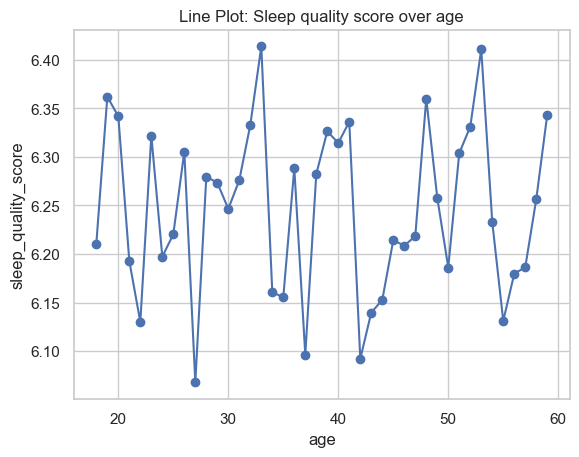

In [12]:
sns.set_theme(style="whitegrid")
fig, ax = plt.subplots()

df_sleep_by_age = df_update.copy()
group_by_age = df_sleep_by_age.groupby("age")["sleep_quality_score"].mean()
x = group_by_age.index
y = group_by_age.values
ax.plot(x, y, marker = "o")
ax.set_title("Line Plot: Sleep quality score over age")
ax.set_xlabel("age")
ax.set_ylabel("sleep_quality_score")
plt.show()

In [13]:
df_groupby_age = df_update.copy()
sleepPerAge= df_groupby_age.groupby("age")["sleep_quality_score"].mean()
sleepPerAge = sleepPerAge.to_frame()
sleepPerAge.iloc[:, [0]]

,sleep_quality_score
age,
18,6.210710
19,6.362000
20,6.341800
21,6.192761
22,6.130000
23,6.321966
24,6.197287
25,6.220358
26,6.305517


In [14]:
df_update.describe()

,user_id,age,daily_screen_time_hours,phone_usage_before_sleep_minutes,sleep_duration_hours,sleep_quality_score,stress_level,caffeine_intake_cups,physical_activity_minutes,notifications_received_per_day,mental_fatigue_score,daily_screen_time_minutes
count,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.00000,15000.000000,15000.000000,15000.000000,15000.00000
mean,7500.500000,38.488467,5.501528,59.708933,6.509683,6.246362,6.980247,1.99880,59.157133,160.890467,6.873009,330.09168
std,4330.271354,12.007970,2.600085,34.641858,1.452689,1.713644,2.749382,1.41459,34.525705,80.856902,2.730482,156.00507
min,1.000000,18.000000,1.000000,0.000000,4.000000,1.000000,1.000000,0.00000,0.000000,20.000000,1.000000,60.00000
25%,3750.750000,28.000000,3.260000,29.000000,5.260000,5.000000,4.750000,1.00000,29.000000,92.000000,4.700000,195.60000
50%,7500.500000,38.000000,5.490000,60.000000,6.490000,6.250000,7.380000,2.00000,59.000000,162.000000,7.380000,329.40000
75%,11250.250000,49.000000,7.760000,90.000000,7.790000,7.500000,10.000000,3.00000,89.000000,231.000000,9.450000,465.60000
max,15000.000000,59.000000,10.000000,119.000000,9.000000,10.000000,10.000000,4.00000,119.000000,299.000000,10.000000,600.00000
